/Users/hwangdayoung/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


              v         a       sin   FC_msec  FC_Label
count  72119.00  72119.00  72119.00  72119.00  72119.00
mean       0.33     -0.00     -0.00      9.00      1.92
std        0.25      0.25      0.22      7.70      1.30
min        0.00     -1.99     -1.00      0.00      0.00
25%        0.08     -0.07     -0.05      2.69      1.00
50%        0.33      0.00      0.00      6.66      2.00
75%        0.50      0.09      0.05     13.31      3.00
max        1.00      1.70      1.00     46.85      6.00
FC_Label
1.0    28740
2.0    17062
3.0    10346
4.0     6446
0.0     5723
5.0     3734
6.0       68
Name: count, dtype: int64


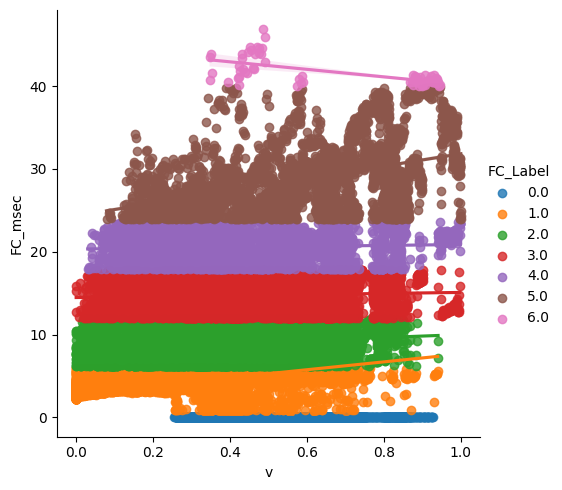

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras

# Feature : v(speed) = v / v_max     a(acceleration) = a * 5     sin(gradient)
# Target : FC_Label = 0 ~ 6

FC = pd.read_csv('FC_new.csv')
print(FC.describe().round(2))
print(FC['FC_Label'].value_counts())

sns.lmplot(data=FC, x='v', y='FC_msec', hue='FC_Label')
plt.show()

In [2]:
arr_x = FC[['v','a','sin']].to_numpy()
arr_y = FC['FC_Label'].to_numpy()

SEQ_LEN = 10  # 시퀀스 길이
X_seq, y_seq = [], []
for i in range(len(arr_x) - SEQ_LEN + 1):
    X_seq.append(arr_x[i:i+SEQ_LEN])
    y_seq.append(arr_y[i+SEQ_LEN-1])

feature = np.array(X_seq)  # (N, SEQ_LEN, 3)
target = np.array(y_seq)

train_input, test_input, train_target, test_target = train_test_split(feature, target, test_size=0.2, random_state=42) 
val_input, test_input, val_target, test_target = train_test_split(test_input, test_target, test_size=0.5, random_state=42) 
print(train_input.shape, val_input.shape, test_input.shape)   
print(train_target.shape, val_target.shape, test_target.shape)   

(57688, 10, 3) (7211, 10, 3) (7211, 10, 3)
(57688,) (7211,) (7211,)


Epoch 1/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6239 - loss: 0.9399 - val_accuracy: 0.7586 - val_loss: 0.6006
Epoch 2/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7307 - loss: 0.6574 - val_accuracy: 0.7160 - val_loss: 0.6492
Epoch 3/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7482 - loss: 0.6250 - val_accuracy: 0.7594 - val_loss: 0.5699
Epoch 4/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7558 - loss: 0.6022 - val_accuracy: 0.7777 - val_loss: 0.5488
Epoch 5/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7577 - loss: 0.5932 - val_accuracy: 0.7744 - val_loss: 0.5480
Epoch 6/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7657 - loss: 0.5805 - val_accuracy: 0.7742 - val_loss: 0.5652
Epoch 7/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7707 - loss: 0.5704 - val_accuracy: 0.7801 - val_loss: 0.5303
Epoch 8/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7743 - loss: 0.5601 - 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 64)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,671 (201.84 KB)

 Trainable params: 17,223 (67.28 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,448 (134.57 KB)

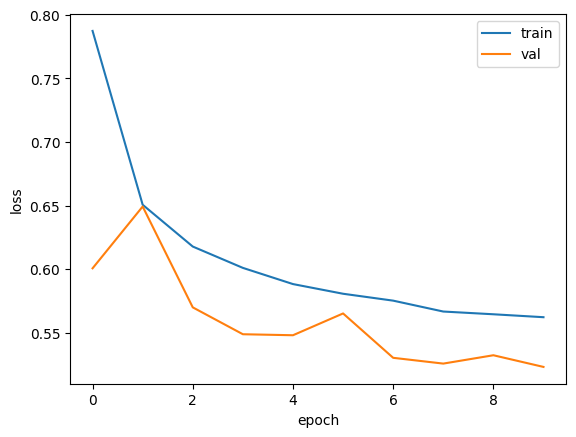

In [3]:
model = keras.Sequential()
model.add(keras.layers.SimpleRNN(64, return_sequences=True)) # 각 셀의 출력을 상위 셀에 바로 입력
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.SimpleRNN(64, return_sequences=False)) # 최종 셀의 출력만 밀집층으로 입력
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(7, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_input, train_target, epochs=10, validation_data=(val_input, val_target))
model.summary()
model.save('FC_class_SimpleRNN.keras')
plt.plot(history.history['loss']) 
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()


In [4]:
np.random.seed(42)
num = 5
ind = np.random.choice(len(test_input), num)
p = model.predict(test_input[ind]).round(3)
y = np.argmax(p, axis=1)
t = test_target[ind]
print(ind) 
print(p)
print(y)
print(t)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
[ 860 5390 5226 5191 3772]
[[0.    0.999 0.001 0.    0.    0.    0.   ]
 [0.122 0.103 0.49  0.132 0.097 0.043 0.012]
 [0.461 0.134 0.376 0.022 0.001 0.006 0.   ]
 [0.913 0.05  0.036 0.001 0.    0.    0.   ]
 [0.001 0.994 0.005 0.    0.    0.    0.   ]]
[1 2 0 0 1]
[1. 2. 0. 0. 1.]


226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step
Confusion Matrix:
 [[ 497   68   24    0    0    0    0]
 [ 103 2513  250    2    0    0    0]
 [  46  153 1396   69   19    0    0]
 [   3    4  286  566  157    8    0]
 [   0    1   28  125  434   69    0]
 [   0    0   10    6   70  297    0]
 [   0    0    0    0    0    7    0]]
Accuracy: 0.791
Precision: [0.766 0.917 0.7   0.737 0.638 0.78  0.   ]
Recall (Sensitivity): [0.844 0.876 0.829 0.553 0.661 0.775 0.   ]
F1 Score: [0.803 0.896 0.759 0.632 0.649 0.777 0.   ]


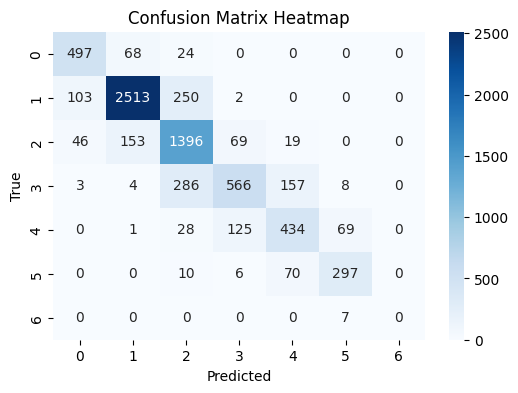

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
test_pred = np.argmax(model.predict(test_input), axis=1)
cm = confusion_matrix(test_target, test_pred)
accuracy = round(accuracy_score(test_target, test_pred), 3)
precision = precision_score(test_target, test_pred, average=None, zero_division=0).round(3)
recall = recall_score(test_target, test_pred, average=None, zero_division=0).round(3)
f1 = f1_score(test_target, test_pred, average=None, zero_division=0).round(3)
# average = None(모든 레이블에 대해) / = 'macro' : 평균 / zero_division=0 : 예측 수가 0인 경우 처리

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall (Sensitivity): {recall}")
print(f"F1 Score: {f1}")

# 히트맵 그리기 : format=digit (정수로 표시)
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()


# 연습문제04

Epoch 1/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6178 - loss: 0.9433 - val_accuracy: 0.7468 - val_loss: 0.6411
Epoch 2/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7249 - loss: 0.6730 - val_accuracy: 0.7446 - val_loss: 0.6182
Epoch 3/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7389 - loss: 0.6386 - val_accuracy: 0.7744 - val_loss: 0.5652
Epoch 4/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7474 - loss: 0.6180 - val_accuracy: 0.7745 - val_loss: 0.5525
Epoch 5/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7512 - loss: 0.6125 - val_accuracy: 0.7737 - val_loss: 0.5593
Epoch 6/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7504 - loss: 0.6098 - val_accuracy: 0.7788 - val_loss: 0.5368
Epoch 7/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7535 - loss: 0.6014 - val_accuracy: 0.7652 - val_loss: 0.5676
Epoch 8/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7603 - loss: 0.5971 - 

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 6, 64)          │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,671 (201.84 KB)

 Trainable params: 17,223 (67.28 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,448 (134.57 KB)

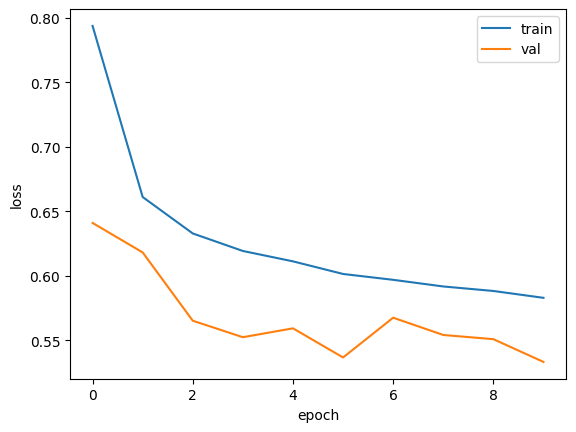

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
[1 1 3 2 2] [1. 1. 3. 1. 1.]
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step
0.788
[0.789 0.888 0.728 0.674 0.692 0.765 0.   ]


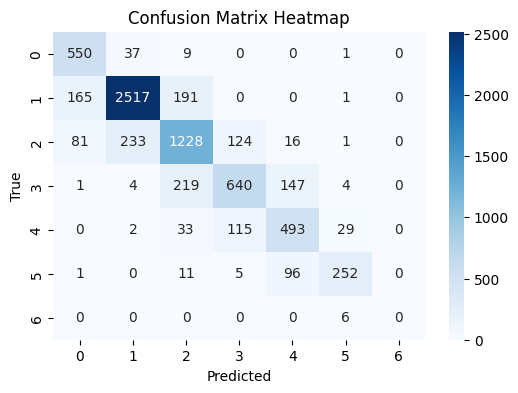

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras

FC = pd.read_csv('FC_new.csv')
arr_x = FC[['v','a','sin']].to_numpy()
arr_y = FC['FC_Label'].to_numpy()
SEQ_LEN = 6
X_seq, y_seq = [], []
for i in range(len(arr_x) - SEQ_LEN + 1):
    X_seq.append(arr_x[i:i+SEQ_LEN])
    y_seq.append(arr_y[i+SEQ_LEN-1])

feature = np.array(X_seq) 
target = np.array(y_seq)

train_input, test_input, train_target, test_target = train_test_split(feature, target, test_size=0.2, random_state=42) 
val_input, test_input, val_target, test_target = train_test_split(test_input, test_target, test_size=0.5, random_state=42) 

model = keras.Sequential()
model.add(keras.layers.SimpleRNN(64, return_sequences=True))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.SimpleRNN(64, return_sequences=False))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(7, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_input, train_target, epochs=10, validation_data=(val_input, val_target))
model.summary()
model.save('FC_class_SimpeRNN.keras')
plt.plot(history.history['loss']) 
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

np.random.seed(42)
num = 5
ind = np.random.choice(len(test_input), num)
p = model.predict(test_input[ind]).round(3)
y = np.argmax(p, axis=1)
t = test_target[ind]
print(y, t)

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
test_pred = np.argmax(model.predict(test_input), axis=1)
cm = confusion_matrix(test_target, test_pred)
accuracy = round(accuracy_score(test_target, test_pred), 3)
precision = precision_score(test_target, test_pred, average=None, zero_division=0).round(3)
recall = recall_score(test_target, test_pred, average=None, zero_division=0).round(3)
f1 = f1_score(test_target, test_pred, average=None, zero_division=0).round(3)
print(accuracy)
print(f1)

import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

Epoch 1/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 20.8430 - val_loss: 7.2669
Epoch 2/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 10.6515 - val_loss: 7.1626
Epoch 3/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 9.4146 - val_loss: 8.6547
Epoch 4/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8.6705 - val_loss: 6.7774
Epoch 5/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8.7339 - val_loss: 6.2194
Epoch 6/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8.6344 - val_loss: 5.9606
Epoch 7/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8.2343 - val_loss: 6.3827
Epoch 8/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.9915 - val_loss: 5.6524
Epoch 9/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.9490 - val_loss: 5.9176
Epoch 10/10
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.6860 - val_loss: 6.4684


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 12, 64)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,133 (438.02 KB)

 Trainable params: 37,377 (146.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 74,756 (292.02 KB)

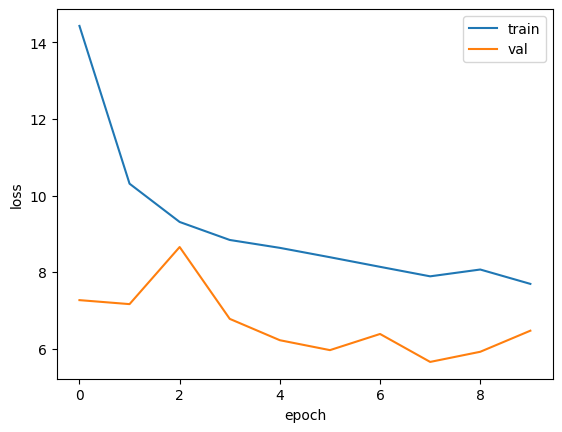

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
[ 860 5390 5226 5191 3772]
[ 2.761 13.864  1.127  0.983  4.171]
[2.56  9.728 0.    0.    3.84 ]
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step
[ 6.89  2.62  1.64 18.16  0.89  0.95]


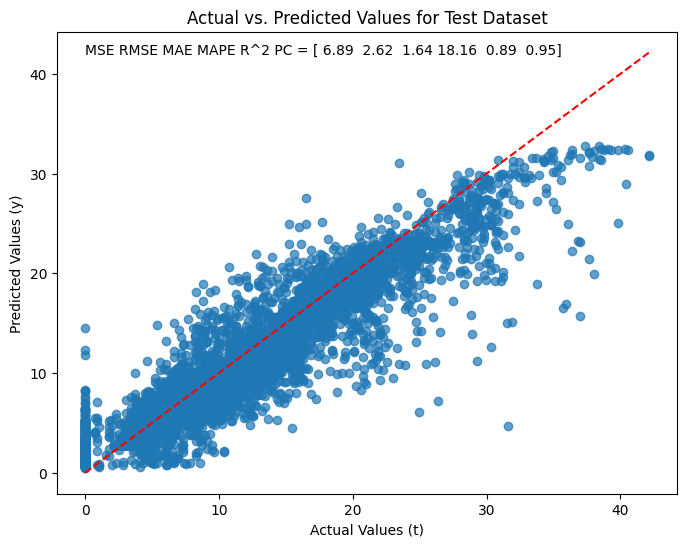

In [9]:
# Regression Model

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras

FC = pd.read_csv('FC_new.csv')
arr_x = FC[['v','a','sin']].to_numpy()
arr_y = FC['FC_msec'].to_numpy()   # 실제 연료소모량 (msec 단위)
SEQ_LEN = 12 
X_seq, y_seq = [], []
for i in range(len(arr_x) - SEQ_LEN + 1):
    X_seq.append(arr_x[i:i+SEQ_LEN])
    y_seq.append(arr_y[i+SEQ_LEN-1])

feature = np.array(X_seq)  
target = np.array(y_seq)
train_input, test_input, train_target, test_target = train_test_split(feature, target, test_size=0.2, random_state=42) 
val_input, test_input, val_target, test_target= train_test_split(test_input, test_target, test_size=0.5, random_state=42) 

model = keras.Sequential()
model.add(keras.layers.SimpleRNN(64, return_sequences=True))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.SimpleRNN(128, return_sequences=False))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1))
model.compile(optimizer='adam', loss='mse')
history = model.fit(train_input, train_target, epochs=10, validation_data=(val_input, val_target))
model.summary()
model.save('FC_reg_SimpleRNN.keras')
plt.plot(history.history['loss']) 
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

np.random.seed(42)
num = 5
ind = np.random.choice(len(test_input), num)
y = model.predict(test_input[ind]).round(3).flatten()
t = test_target[ind].round(3)
print(ind) 
print(y)
print(t)

y = model.predict(test_input).reshape(-1)
t = test_target
Diff = np.abs(t - y)
N = len(t)
MSE  = sum(Diff**2) / N
RMSE = np.sqrt(MSE)
MAE  = sum(np.abs(Diff)) / N
MAPE = 100 * np.mean(Diff) / np.mean(np.abs(t))
R_squared = 1 - sum(Diff**2) / sum((t - np.mean(t))**2)
PC = np.corrcoef(t, y)[0, 1]
Error = np.array([MSE, RMSE, MAE, MAPE, R_squared, PC]).round(2)
print(Error)

plt.figure(figsize=(8, 6))
plt.scatter(t, y, alpha=0.7)
plt.plot([min(t), max(t)], [min(t), max(t)], 'r--')
plt.xlabel('Actual Values (t)')
plt.ylabel('Predicted Values (y)')
plt.title('Actual vs. Predicted Values for Test Dataset')
plt.text(0, 42, f'MSE RMSE MAE MAPE R^2 PC = {Error}')
plt.show()


In [10]:
a = np.arange(36).reshape(-1, 3)
print(a)

SEQ_LEN = 4
a_seq = []
for i in range(len(a) - SEQ_LEN + 1):
    a_seq.append(a[i:i+SEQ_LEN])
    
feature = np.array(a_seq) 
print(feature.shape)
print(feature)

b, c = train_test_split(feature, test_size=0.2, random_state=42) 
print(c)


[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]
 [15 16 17]
 [18 19 20]
 [21 22 23]
 [24 25 26]
 [27 28 29]
 [30 31 32]
 [33 34 35]]
(9, 4, 3)
[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]
  [ 9 10 11]]

 [[ 3  4  5]
  [ 6  7  8]
  [ 9 10 11]
  [12 13 14]]

 [[ 6  7  8]
  [ 9 10 11]
  [12 13 14]
  [15 16 17]]

 [[ 9 10 11]
  [12 13 14]
  [15 16 17]
  [18 19 20]]

 [[12 13 14]
  [15 16 17]
  [18 19 20]
  [21 22 23]]

 [[15 16 17]
  [18 19 20]
  [21 22 23]
  [24 25 26]]

 [[18 19 20]
  [21 22 23]
  [24 25 26]
  [27 28 29]]

 [[21 22 23]
  [24 25 26]
  [27 28 29]
  [30 31 32]]

 [[24 25 26]
  [27 28 29]
  [30 31 32]
  [33 34 35]]]
[[[21 22 23]
  [24 25 26]
  [27 28 29]
  [30 31 32]]

 [[ 3  4  5]
  [ 6  7  8]
  [ 9 10 11]
  [12 13 14]]]
